# BQIS v3 — Production-Ready Pipeline + Robustness Module
### Versi lengkap: seluruh pipeline BQIS_04 + penutup gap robustness.

**Baseline dari BQIS_04 (tidak diubah):**
1. **Column mapping** — nama kolom dari LIMS asli bisa beda, pipeline nggak boleh hardcode
2. **Threshold missing 30%** — sesuai proposal Layer 1
3. **eps DBSCAN otomatis** (k-distance graph)
4. **Validasi fleksibel** — fallback ke Silhouette Score kalau ground truth tidak tersedia

**Tambahan robustness (gap yang ditutup di notebook ini):**
5. **Outlier detection (IQR)** — diklaim di Layer 1 proposal, sekarang diimplementasi
6. **Validasi tipe data** — teks nyasar di kolom numerik ditangani, bukan crash
7. **Adaptive parameters** — n_neighbors & min_samples menyesuaikan ukuran sampel
8. **Duplicate check** — Sample_ID ganda di-flag
9. **Pipeline summary report** — ringkasan akhir untuk presentasi

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

warnings.filterwarnings('ignore', category=FutureWarning)
np.random.seed(42)
print("Imports OK")

Imports OK


## 1. Column Mapping (Config, Bukan Hardcode)
Kalau data asli TÜV NORD nama kolomnya beda (misal dari LIMS mereka), cukup ubah dictionary
ini — SATU tempat, nggak perlu rewrite seluruh kode di bawahnya.

In [2]:
# Ganti value di kanan sesuai nama kolom asli dari sumber data baru.
# Key (kiri) = nama standar yang dipakai internal pipeline BQIS, JANGAN diubah.
COLUMN_MAP = {
    'sample_id':        'Sample_ID',
    'batch_code':       'Batch_Code',
    'product_name':     'Product_Name',
    'test_date':        'Test_Date',
    'moisture':         'Moisture_Content_%',
    'fat':              'Fat_Content_%',
    'protein':          'Protein_Content_%',
    'water_activity':   'Water_Activity_Aw',
    'acid_insol_ash':   'Acid_Insoluble_Ash_%',
    'acid_value':       'Acid_Value_mgKOHg',
    'peroxide':         'Peroxide_Value',
    'tpc':              'Total_Plate_Count_CFUg',
    'yeast_mold':       'Yeast_Mold_Count_CFUg',
    'lead':              'Lead_Pb_mgkg',
    'cadmium':          'Cadmium_Cd_mgkg',
    'status':           'Historical_Status',
    'failure_category': 'Failure_Category',   # opsional, boleh None kalau data asli nggak punya ini
}

NUMERIC_FEATURES = ['moisture', 'fat', 'protein', 'water_activity', 'acid_insol_ash',
                     'acid_value', 'peroxide', 'tpc', 'yeast_mold', 'lead', 'cadmium']

# Ambang batas resmi SNI 2973:2022 (ISI SESUAI ANGKA DI DOKUMEN SNI ASLI KALIAN).
# Ini placeholder -- isi manual dari dokumen SPC-TNI-020 / SNI 2973:2022 yang kalian punya.
SNI_LIMITS = {
    'moisture':       {'max': 5.0},   # contoh: {'max': 5.0}
    'acid_insol_ash': {'max': 0.1},
    'acid_value':     {'max': 1.0},
    'lead':           {'max': 0.5},
    'cadmium':        {'max': 0.2},
    'tpc':            {'max': 10000},
    'yeast_mold':     {'max': 1000},
}

# ── Config Robustness (BARU) ──────────────────────────────────────────────────
IQR_MULTIPLIER = 1.5          # 1.5 = standar, 3.0 = longgar (cuma flag yg super ekstrem)
MISSING_THRESHOLD = 0.30      # sampel >30% missing → manual review
TOP_N_FEATURES = 5            # jumlah fitur terpilih

print("Config siap. NUMERIC_FEATURES:", len(NUMERIC_FEATURES), "parameter")
print("IQR Multiplier:", IQR_MULTIPLIER)
print(">> TODO: isi SNI_LIMITS dengan angka baku mutu resmi sebelum dipakai ke data asli.")

Config siap. NUMERIC_FEATURES: 11 parameter
IQR Multiplier: 1.5
>> TODO: isi SNI_LIMITS dengan angka baku mutu resmi sebelum dipakai ke data asli.


## 2. Load & Standardize
Fungsi ini yang bakal dipanggil tiap kali ada dataset baru — tinggal ganti `path` dan
`COLUMN_MAP` di atas, logic di bawah nggak perlu disentuh.

In [3]:
def load_and_standardize(path, column_map=COLUMN_MAP):
    df_raw = pd.read_csv(path)
    reverse_map = {v: k for k, v in column_map.items() if v is not None}
    df_std = df_raw.rename(columns=reverse_map)

    missing_cols = [k for k in column_map if k not in df_std.columns and k != 'failure_category']
    if missing_cols:
        print(f"[WARNING] Kolom berikut tidak ditemukan di data baru: {missing_cols}")
        print("          Cek COLUMN_MAP -- kemungkinan nama kolom sumber berbeda.")
    return df_std

df = load_and_standardize("../data/bqis_biscuit_quality_dataset_5000.csv")
print(df.shape)
df.head(3)

(5050, 17)


,sample_id,batch_code,product_name,test_date,moisture,fat,protein,water_activity,acid_insol_ash,acid_value,peroxide,tpc,yeast_mold,lead,cadmium,failure_category,status
0,SPL-2026-0001,B-251122-1,Butter Biscuit,2025-11-24,3.4,17.45,7.47,0.672,0.035,0.73,1.53,4535,206,0.204,0.031,NaN,Pass
1,SPL-2026-0002,B-250422-2,Butter Biscuit,2025-04-25,2.63,18.97,3.63,0.412,0.029,0.5,1.03,1184,18,NaN,0.041,NaN,Pass
2,SPL-2026-0003,B-250804-1,Wafer Vanilla,2025-08-05,3.05,12.3,5.68,0.559,0.017,0.91,0.66,2417,180,0.335,0.049,NaN,Pass


## 2.5 Validasi Tipe Data & Format *(BARU — Gap #2)*
Kalau ada sel yang isinya teks nyasar (misal `"N/A"`, `"-"`, atau typo) di kolom numerik,
KNNImputer bakal crash (`ValueError: could not convert string to float`).

Solusi: paksa konversi ke numerik via `pd.to_numeric(errors='coerce')` — sel yang gagal
konversi jadi `NaN` (lalu ditangani oleh KNN Imputer di Section 3), bukan crash.
Jumlah sel yang di-coerce dilaporkan supaya auditor tahu ada data bermasalah.

In [4]:
def validate_and_coerce_types(df, numeric_features=NUMERIC_FEATURES):
    """
    Paksa kolom numerik ke float. Teks nyasar ('N/A', '-', typo) jadi NaN.
    Return: df yang sudah bersih tipe datanya + dict laporan per kolom.
    """
    df = df.copy()
    coercion_report = {}
    total_coerced = 0

    for col in numeric_features:
        if col not in df.columns:
            continue
        before_na = df[col].isna().sum()
        df[col] = pd.to_numeric(df[col], errors='coerce')
        after_na = df[col].isna().sum()
        n_coerced = after_na - before_na
        if n_coerced > 0:
            coercion_report[col] = n_coerced
            total_coerced += n_coerced

    if total_coerced > 0:
        print(f"[WARNING] {total_coerced} sel teks nyasar dikonversi ke NaN:")
        for col, n in coercion_report.items():
            print(f"  - {col}: {n} sel")
        print("  Sel-sel ini akan ditangani oleh KNN Imputer di Section 3.")
    else:
        print("[OK] Semua kolom numerik sudah bertipe benar. Tidak ada teks nyasar.")

    return df, coercion_report

df, coercion_report = validate_and_coerce_types(df)
# Simpan untuk summary report
_report = {'total_loaded': len(df), 'coerced_cells': sum(coercion_report.values()) if coercion_report else 0}

[WARNING] 71 sel teks nyasar dikonversi ke NaN:
  - moisture: 3 sel
  - fat: 4 sel
  - protein: 6 sel
  - water_activity: 4 sel
  - acid_insol_ash: 7 sel
  - acid_value: 7 sel
  - peroxide: 10 sel
  - tpc: 7 sel
  - yeast_mold: 3 sel
  - lead: 9 sel
  - cadmium: 11 sel
  Sel-sel ini akan ditangani oleh KNN Imputer di Section 3.


## 2.7 Duplicate Sample_ID Check *(BARU — Gap #5)*
Belum ada pengecekan duplikat sama sekali di v1/v2/v3 sebelumnya.
Duplikat di-**flag** (bukan otomatis dihapus) — bisa jadi re-test yang valid.

In [5]:
def check_duplicates(df, id_col='sample_id'):
    """
    Flag Sample_ID yang muncul lebih dari sekali.
    Tidak otomatis drop — bisa jadi re-test yang valid.
    """
    df = df.copy()
    if id_col not in df.columns:
        print(f"[INFO] Kolom '{id_col}' tidak ditemukan, skip duplicate check.")
        df['is_duplicate'] = False
        return df, 0

    dup_mask = df.duplicated(subset=[id_col], keep=False)
    df['is_duplicate'] = dup_mask
    n_dup = dup_mask.sum()

    if n_dup > 0:
        print(f"[WARNING] {n_dup} baris dengan Sample_ID duplikat ditemukan:")
        dup_ids = df.loc[dup_mask, id_col].unique()
        for did in dup_ids[:10]:  # tampilkan max 10
            count = (df[id_col] == did).sum()
            print(f"  - {did} (muncul {count}x)")
        if len(dup_ids) > 10:
            print(f"  ... dan {len(dup_ids) - 10} ID lainnya.")
        print("  → Di-flag di kolom 'is_duplicate'. TIDAK dihapus otomatis.")
    else:
        print("[OK] Tidak ada Sample_ID duplikat.")

    return df, n_dup

df, n_duplicates = check_duplicates(df)
_report['n_duplicates'] = n_duplicates

[WARNING] 100 baris dengan Sample_ID duplikat ditemukan:
  - SPL-2026-0029 (muncul 2x)
  - SPL-2026-0152 (muncul 2x)
  - SPL-2026-0232 (muncul 2x)
  - SPL-2026-0277 (muncul 2x)
  - SPL-2026-0284 (muncul 2x)
  - SPL-2026-0308 (muncul 2x)
  - SPL-2026-0429 (muncul 2x)
  - SPL-2026-0440 (muncul 2x)
  - SPL-2026-0618 (muncul 2x)
  - SPL-2026-0695 (muncul 2x)
  ... dan 40 ID lainnya.
  → Di-flag di kolom 'is_duplicate'. TIDAK dihapus otomatis.


## 3. Missing-Value Handling Sesuai Proposal (Threshold 30%)
Ini implementasi konkret dari klaim di Layer 1 proposal: *"Samples with more than 30%
missing parameter values are excluded from AI analysis and flagged for manual review."*

**Modifikasi v3-Robust:** `n_neighbors` di KNNImputer sekarang **adaptive** — kalau
sampel sedikit (misal n=3), otomatis turun dari 5 ke `n-1`. Kalau terlalu sedikit
bahkan untuk KNN, fallback ke median imputation. *(Gap #3)*

In [6]:
def flag_and_impute(df, numeric_features=NUMERIC_FEATURES, missing_threshold=MISSING_THRESHOLD, n_neighbors_target=5):
    missing_pct = df[numeric_features].isna().sum(axis=1) / len(numeric_features)
    df = df.copy()
    df['flag_manual_review'] = missing_pct > missing_threshold

    n_flagged = df['flag_manual_review'].sum()
    print(f"Sampel di-flag manual review (missing >{missing_threshold*100:.0f}%): {n_flagged}/{len(df)} ({n_flagged/len(df)*100:.1f}%)")

    df_clean = df[~df['flag_manual_review']].reset_index(drop=True)
    df_flagged = df[df['flag_manual_review']].reset_index(drop=True)

    # ── Adaptive n_neighbors (BARU — Gap #3) ─────────────────────────────────
    n_available = len(df_clean)
    n_neighbors = min(n_neighbors_target, n_available - 1)

    if n_neighbors >= 1:
        print(f"KNN Imputer: n_neighbors={n_neighbors} (target={n_neighbors_target}, available={n_available})")
        imputer = KNNImputer(n_neighbors=n_neighbors, weights='distance')
        df_clean[numeric_features] = imputer.fit_transform(df_clean[numeric_features])
    else:
        # Fallback: median imputation kalau sampel terlalu sedikit untuk KNN
        print(f"[WARNING] Sampel terlalu sedikit untuk KNN (n={n_available}). Fallback ke median imputation.")
        for col in numeric_features:
            if col in df_clean.columns:
                median_val = df_clean[col].median()
                if pd.notna(median_val):
                    df_clean[col] = df_clean[col].fillna(median_val)
                else:
                    df_clean[col] = df_clean[col].fillna(0)

    return df_clean, df_flagged

df_clean, df_flagged = flag_and_impute(df)
print(f"\nSiap dianalisis AI: {len(df_clean)} sampel")
print(f"Perlu manual review auditor: {len(df_flagged)} sampel (TIDAK diproses AI, sesuai proposal)")
_report['n_manual_review'] = len(df_flagged)
_report['n_ai_ready'] = len(df_clean)

Sampel di-flag manual review (missing >30%): 144/5050 (2.9%)
KNN Imputer: n_neighbors=5 (target=5, available=4906)

Siap dianalisis AI: 4906 sampel
Perlu manual review auditor: 144 sampel (TIDAK diproses AI, sesuai proposal)


## 3.5 Outlier Detection — IQR Flagging *(BARU — Gap #1, KRITIS)*
**Ini gap paling serius.** Layer 1 proposal BQIS eksplisit mengklaim:
> *"...this layer automatically manages format validation, conditional missing values, **outlier detection**, and correlation analysis..."*

Tapi sampai v3 sebelumnya, belum ada kode outlier detection sama sekali.

### Filosofi Desain: FLAG, Bukan BUANG
Sampel outlier **di-flag, TIDAK otomatis dihapus**. Alasan:
- Case statement BQIS menyebut *"high production batch variation"* sebagai fenomena valid
- Kalau outlier dibuang otomatis → risiko membuang variasi produksi asli
- BQIS adalah **decision-support**, bukan pengambil keputusan mandiri

Outlier tetap ikut masuk ke proses clustering — tapi kolom flag-nya bisa dipakai
auditor untuk filter/review setelah hasil keluar.

In [7]:
def detect_outliers_iqr(df, numeric_features=NUMERIC_FEATURES, multiplier=IQR_MULTIPLIER):
    """
    Deteksi outlier per parameter numerik menggunakan metode IQR.
    - Flag sampel di luar [Q1 - multiplier*IQR, Q3 + multiplier*IQR]
    - Tambah kolom 'is_outlier_{param}' per parameter
    - Tambah kolom 'n_outlier_flags' (total flag per sampel)
    - TIDAK menghapus sampel — cuma flag untuk human review
    """
    df = df.copy()
    outlier_summary = {}

    for col in numeric_features:
        if col not in df.columns:
            continue
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - multiplier * IQR
        upper = Q3 + multiplier * IQR

        is_outlier = (df[col] < lower) | (df[col] > upper)
        df[f'is_outlier_{col}'] = is_outlier
        n_out = is_outlier.sum()
        outlier_summary[col] = {
            'n_outlier': n_out,
            'pct': round(n_out / len(df) * 100, 1),
            'lower_bound': round(lower, 4),
            'upper_bound': round(upper, 4)
        }

    # Total outlier flags per sampel
    outlier_cols = [f'is_outlier_{col}' for col in numeric_features if f'is_outlier_{col}' in df.columns]
    df['n_outlier_flags'] = df[outlier_cols].sum(axis=1)

    # Print summary
    print(f"Outlier Detection (IQR × {multiplier})")
    print(f"{'Parameter':<20} {'Outliers':>8} {'%':>7}  {'Lower':>10}  {'Upper':>10}")
    print("-" * 62)
    total_outlier_samples = 0
    for col, info in outlier_summary.items():
        marker = " ⚠" if info['n_outlier'] > 0 else ""
        print(f"{col:<20} {info['n_outlier']:>8} {info['pct']:>6.1f}%  {info['lower_bound']:>10.4f}  {info['upper_bound']:>10.4f}{marker}")
    
    n_any_outlier = (df['n_outlier_flags'] > 0).sum()
    print(f"\nSampel dengan ≥1 outlier flag: {n_any_outlier}/{len(df)} ({n_any_outlier/len(df)*100:.1f}%)")
    print("→ Sampel TIDAK dihapus. Flag untuk review auditor.")

    return df, outlier_summary

df_clean, outlier_summary = detect_outliers_iqr(df_clean)
_report['n_outlier_samples'] = (df_clean['n_outlier_flags'] > 0).sum()

Outlier Detection (IQR × 1.5)
Parameter            Outliers       %       Lower       Upper
--------------------------------------------------------------
moisture                  112    2.3%      0.7700      5.2500 ⚠
fat                        35    0.7%      7.1687     28.7988 ⚠
protein                    67    1.4%      2.5550     10.4350 ⚠
water_activity             38    0.8%      0.3380      0.7620 ⚠
acid_insol_ash             86    1.8%     -0.0135      0.0945 ⚠
acid_value                 79    1.6%     -0.0150      1.6250 ⚠
peroxide                    7    0.1%     -0.2100      2.0300 ⚠
tpc                       115    2.3%  -2284.0000   8530.0000 ⚠
yeast_mold                103    2.1%   -250.5000    857.5000 ⚠
lead                      106    2.2%     -0.1185      0.4295 ⚠
cadmium                   101    2.1%     -0.0570      0.1590 ⚠

Sampel dengan ≥1 outlier flag: 825/4906 (16.8%)
→ Sampel TIDAK dihapus. Flag untuk review auditor.


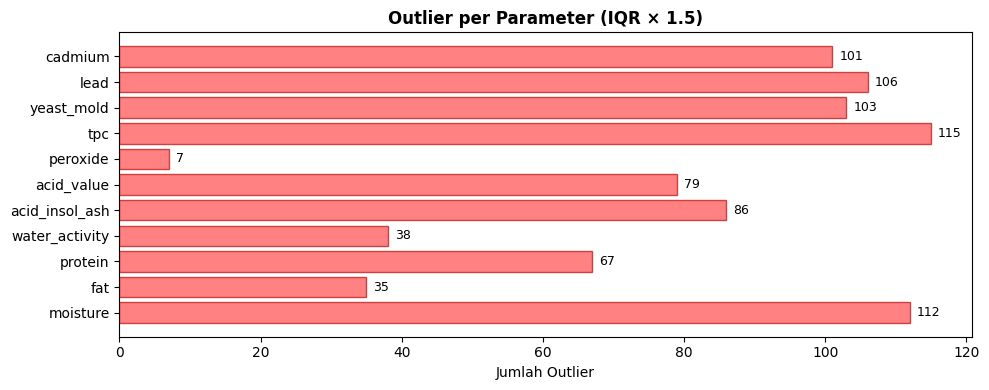

In [8]:
# Visualisasi distribusi outlier per parameter
outlier_counts = {col: info['n_outlier'] for col, info in outlier_summary.items()}
cols_with_outliers = {k: v for k, v in outlier_counts.items() if v > 0}

if cols_with_outliers:
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.barh(list(cols_with_outliers.keys()), list(cols_with_outliers.values()),
                   color='#ff6b6b', edgecolor='#c92a2a', alpha=0.85)
    ax.set_xlabel('Jumlah Outlier')
    ax.set_title(f'Outlier per Parameter (IQR × {IQR_MULTIPLIER})', fontweight='bold')
    for bar, val in zip(bars, cols_with_outliers.values()):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("[OK] Tidak ada outlier terdeteksi di parameter manapun.")

## 4. Cross-Check ke Baku Mutu SNI (Bukan Cuma Statistik)
Ini yang belum ada sama sekali di v1/v2 — pipeline sekarang cuma belajar pola statistik,
padahal kalian sudah punya dokumen SNI 2973:2022 dengan angka baku mutu resmi.
Menjangkarkan hasil ke standar resmi = argumen kuat untuk kredibilitas ke auditor TÜV NORD.

In [9]:
def check_sni_compliance(df, sni_limits=SNI_LIMITS):
    results = {}
    for param, limit in sni_limits.items():
        if limit.get('max') is None or param not in df.columns:
            continue
        exceed = (df[param] > limit['max']).sum()
        results[param] = {'n_exceed': exceed, 'pct_exceed': round(exceed/len(df)*100, 1)}
    if not results:
        print("[INFO] SNI_LIMITS masih kosong (placeholder). Isi dulu angka baku mutu resminya di Section 1.")
    else:
        for param, r in results.items():
            print(f"{param}: {r['n_exceed']} sampel melebihi batas SNI ({r['pct_exceed']}%)")
    return results

sni_check = check_sni_compliance(df_clean)
_report['sni_violations'] = sum(r['n_exceed'] for r in sni_check.values())

moisture: 97 sampel melebihi batas SNI (2.0%)
acid_insol_ash: 86 sampel melebihi batas SNI (1.8%)
acid_value: 1244 sampel melebihi batas SNI (25.4%)
lead: 92 sampel melebihi batas SNI (1.9%)
cadmium: 85 sampel melebihi batas SNI (1.7%)
tpc: 104 sampel melebihi batas SNI (2.1%)
yeast_mold: 92 sampel melebihi batas SNI (1.9%)


## 5. Feature Selection — Otomatis, Bukan Hardcode "Top-5"
Kalau `failure_category` TERSEDIA (kayak dataset dummy ini), pakai Mutual Information.
Kalau TIDAK TERSEDIA (kemungkinan besar di data asli), fallback ke variance-based selection.

**Modifikasi v3-Robust:** Tambah guard kalau sampel fail terlalu sedikit. *(Gap #3)*

In [10]:
def select_features(df, numeric_features=NUMERIC_FEATURES, status_col='status',
                     category_col='failure_category', top_n=TOP_N_FEATURES):
    fail_mask = df[status_col].map({'Pass': 0, 'Fail': 1}) == 1
    X_fail = df.loc[fail_mask, numeric_features].reset_index(drop=True)

    # ── Guard: sampel fail terlalu sedikit (BARU — Gap #3) ────────────────────
    if len(X_fail) < 2:
        print(f"[WARNING] Sampel fail terlalu sedikit (n={len(X_fail)}). Pakai semua fitur.")
        return X_fail, numeric_features[:top_n], None, False

    has_ground_truth = category_col in df.columns and df[category_col].notna().any()

    if has_ground_truth:
        cat_ref = df.loc[fail_mask, category_col].reset_index(drop=True)
        # Guard: kalau MI gagal karena kategori terlalu sedikit, fallback
        try:
            mi_scores = mutual_info_classif(X_fail, cat_ref, random_state=42)
            ranking = pd.Series(mi_scores, index=numeric_features).sort_values(ascending=False)
            method = "Mutual Information (ground truth tersedia)"
        except Exception as e:
            print(f"[WARNING] MI gagal ({e}). Fallback ke variance-based.")
            has_ground_truth = False
            cat_ref = None

    if not has_ground_truth:
        scaler_tmp = StandardScaler()
        X_scaled_tmp = scaler_tmp.fit_transform(X_fail)
        ranking = pd.Series(X_scaled_tmp.var(axis=0), index=numeric_features).sort_values(ascending=False)
        cat_ref = None
        method = "Variance-based (FALLBACK -- ground truth TIDAK tersedia)"

    print(f"Metode feature selection: {method}")
    print(ranking.round(4))

    selected = ranking.head(top_n).index.tolist()
    return X_fail, selected, cat_ref, has_ground_truth

X_fail, selected_features, cat_ref, has_gt = select_features(df_clean)
print("\nFitur terpilih:", selected_features)
_report['selected_features'] = selected_features

Metode feature selection: Mutual Information (ground truth tersedia)
acid_value        0.2277
yeast_mold        0.1225
lead              0.1193
tpc               0.1169
cadmium           0.0784
moisture          0.0188
peroxide          0.0166
protein           0.0157
fat               0.0000
water_activity    0.0000
acid_insol_ash    0.0000
dtype: float64

Fitur terpilih: ['acid_value', 'yeast_mold', 'lead', 'tpc', 'cadmium']


## 6. eps DBSCAN Otomatis (k-distance Graph)
Ganti grid-search manual (yang kemarin butuh trial-error tiap ganti dataset) dengan metode
data-driven: plot jarak ke tetangga ke-k, cari titik "siku" (elbow) — itu jadi kandidat eps.

**Modifikasi v3-Robust:** `min_samples` sekarang **adaptive** terhadap ukuran dataset. *(Gap #3)*

In [11]:
def suggest_eps(X_scaled, k=5, candidate_range=None):
    from sklearn.cluster import DBSCAN as _DBSCAN

    # ── Adaptive min_samples (BARU — Gap #3) ─────────────────────────────────
    n_samples = len(X_scaled)
    adaptive_min_samples = min(5, max(2, n_samples // 20))
    # Adaptive k untuk NearestNeighbors juga
    adaptive_k = min(k, n_samples - 1)
    if adaptive_k < 1:
        print("[ERROR] Sampel terlalu sedikit untuk DBSCAN. Skip.")
        return None, adaptive_min_samples

    if candidate_range is None:
        neighbors = NearestNeighbors(n_neighbors=adaptive_k)
        neighbors.fit(X_scaled)
        distances, _ = neighbors.kneighbors(X_scaled)
        k_distances = np.sort(distances[:, -1])
        # ambil rentang dari persentil 10-90% jarak k-NN sebagai kandidat wajar
        lo, hi = np.percentile(k_distances, [10, 90])
        candidate_range = np.linspace(lo, hi, 15)

    best_eps, best_score, results = None, -1, []
    for eps in candidate_range:
        labels = _DBSCAN(eps=eps, min_samples=adaptive_min_samples).fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_pct = (labels == -1).sum() / len(labels)

        # skip kandidat degenerate: cuma 1 cluster, atau noise ekstrem
        if n_clusters < 2 or noise_pct > 0.5 or noise_pct < 0.05:
            results.append((eps, n_clusters, noise_pct, None))
            continue

        score = silhouette_score(X_scaled, labels, sample_size=min(1000, len(X_scaled)), random_state=42)
        results.append((eps, n_clusters, noise_pct, score))
        if score > best_score:
            best_score, best_eps = score, eps

    print(f"min_samples (adaptive): {adaptive_min_samples}")
    print("eps      | n_clusters | noise%  | silhouette")
    for eps, nc, np_, sc in results:
        sc_str = f"{sc:.3f}" if sc is not None else "  (skip)"
        print(f"{eps:.3f}  | {nc:^10} | {np_*100:5.1f}% | {sc_str}")

    if best_eps is None:
        print("\n[WARNING] Tidak ada kandidat eps yang wajar (semua degenerate).")
        print("          Rekomendasi: gunakan K-Means saja untuk dataset ini,")
        print("          DBSCAN tidak cocok untuk struktur density data ini.")
        return None, adaptive_min_samples

    print(f"\nEps terpilih (silhouette tertinggi, kandidat valid): {best_eps:.3f}")
    return best_eps, adaptive_min_samples

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_fail[selected_features])
eps_suggested, adaptive_min_samples = suggest_eps(X_scaled, k=5)
_report['eps'] = eps_suggested
_report['min_samples'] = adaptive_min_samples

min_samples (adaptive): 5
eps      | n_clusters | noise%  | silhouette
0.056  |     24     |  78.9% |   (skip)
0.079  |     8      |  48.9% | -0.332
0.103  |     7      |  34.5% | -0.153
0.127  |     4      |  29.8% | 0.166
0.151  |     2      |  27.8% | 0.422
0.175  |     8      |  24.4% | 0.062
0.198  |     8      |  21.2% | 0.303
0.222  |     9      |  18.4% | 0.330
0.246  |     9      |  15.8% | 0.307
0.270  |     11     |  13.4% | 0.315
0.293  |     7      |  11.6% | 0.343
0.317  |     6      |   9.8% | 0.534
0.341  |     5      |   8.8% | 0.542
0.365  |     2      |   8.0% | 0.620
0.388  |     2      |   7.8% | 0.620

Eps terpilih (silhouette tertinggi, kandidat valid): 0.388


## 7. Clustering + Validasi Fleksibel
Kalau ground truth ADA -> laporkan ARI & NMI (seperti v1/v2).
Kalau ground truth TIDAK ADA -> laporkan Silhouette Score saja + serahkan ke auditor untuk
validasi kualitatif per cluster (bukan angka, tapi tetap actionable).

**Modifikasi v3-Robust:** Pakai `adaptive_min_samples` dari Section 6. *(Gap #3)*

In [12]:
def cluster_and_validate(X_scaled, eps, min_samples_db=5, cat_ref=None, has_ground_truth=False, k_range=range(2,7)):
    # ── Guard: sampel terlalu sedikit untuk clustering ────────────────────────
    if len(X_scaled) < 4:
        print("[ERROR] Sampel terlalu sedikit untuk clustering (n < 4). Skip.")
        return np.zeros(len(X_scaled)), np.full(len(X_scaled), -1), 1

    # Batasi k_range supaya nggak melebihi jumlah sampel
    max_k = min(max(k_range), len(X_scaled) - 1)
    k_range = range(2, max_k + 1) if max_k >= 2 else range(2, 3)

    # K-Means: pilih k via silhouette (selalu bisa dihitung, tidak butuh ground truth)
    sil_scores = {}
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X_scaled)
        sil_scores[k] = silhouette_score(X_scaled, labels, sample_size=min(1000, len(X_scaled)), random_state=42)
    best_k = max(sil_scores, key=sil_scores.get)

    kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    kmeans_labels = kmeans_final.fit_predict(X_scaled)

    # DBSCAN: pakai adaptive min_samples
    if eps is not None:
        db_final = DBSCAN(eps=eps, min_samples=min_samples_db)
        dbscan_labels = db_final.fit_predict(X_scaled)
        n_noise = list(dbscan_labels).count(-1)
        print(f"DBSCAN: eps={eps:.3f}, min_samples={min_samples_db}, noise={n_noise}/{len(X_scaled)} ({n_noise/len(X_scaled)*100:.1f}%)")
    else:
        dbscan_labels = np.full(len(X_scaled), -1)
        print("DBSCAN: SKIP (eps tidak ditemukan, pakai K-Means saja)")

    print(f"K-Means: k={best_k} (silhouette={sil_scores[best_k]:.3f})")

    if has_ground_truth and cat_ref is not None:
        print(f"\n[Ground truth tersedia] Validasi kuantitatif:")
        print(f"  ARI K-Means: {adjusted_rand_score(cat_ref, kmeans_labels):.3f}")
        print(f"  NMI K-Means: {normalized_mutual_info_score(cat_ref, kmeans_labels):.3f}")
        if eps is not None:
            print(f"  ARI DBSCAN : {adjusted_rand_score(cat_ref, dbscan_labels):.3f}")
            print(f"  NMI DBSCAN : {normalized_mutual_info_score(cat_ref, dbscan_labels):.3f}")
    else:
        print(f"\n[Ground truth TIDAK tersedia] Validasi kualitatif diperlukan:")
        print("  -> Silhouette Score di atas jadi satu-satunya sinyal kuantitatif.")
        print("  -> Sampel per cluster perlu direview auditor pangan untuk sanity-check domain.")

    return kmeans_labels, dbscan_labels, best_k

kmeans_labels, dbscan_labels, best_k = cluster_and_validate(
    X_scaled, eps_suggested, min_samples_db=adaptive_min_samples,
    cat_ref=cat_ref, has_ground_truth=has_gt
)
_report['best_k'] = best_k

DBSCAN: eps=0.388, min_samples=5, noise=130/1667 (7.8%)
K-Means: k=3 (silhouette=0.845)

[Ground truth tersedia] Validasi kuantitatif:
  ARI K-Means: 0.129
  NMI K-Means: 0.115
  ARI DBSCAN : 0.433
  NMI DBSCAN : 0.266


## 8. Pipeline Summary Report *(BARU)*
Ringkasan satu tampilan untuk presentasi ke juri — berapa sampel di tiap tahap,
dan apa saja yang di-flag.

In [13]:
def print_summary_report(report):
    w = 58
    print("\n" + "═" * w)
    print("  BQIS v3 — PIPELINE SUMMARY REPORT (with Robustness)")
    print("═" * w)
    print(f"  Total sampel dimuat             : {report.get('total_loaded', '?')}")
    print(f"  Tipe data di-coerce (teks→NaN)  : {report.get('coerced_cells', 0)} sel")
    print(f"  Duplikat Sample_ID              : {report.get('n_duplicates', 0)}")
    print(f"  Sampel missing >30% (→manual)   : {report.get('n_manual_review', 0)}")
    print(f"  Sampel dengan ≥1 outlier flag   : {report.get('n_outlier_samples', 0)}")
    print(f"  Pelanggaran SNI terdeteksi       : {report.get('sni_violations', 0)}")
    print("─" * w)
    print(f"  Sampel siap analisis AI         : {report.get('n_ai_ready', '?')}")
    print(f"  Fitur terpilih                  : {report.get('selected_features', '?')}")
    print(f"  K-Means k terpilih              : {report.get('best_k', '?')}")
    eps_val = report.get('eps', None)
    print(f"  DBSCAN eps terpilih             : {f'{eps_val:.3f}' if eps_val else 'N/A'}")
    print(f"  DBSCAN min_samples (adaptive)   : {report.get('min_samples', '?')}")
    print("═" * w)
    print("  Gap yang ditutup di versi ini:")
    print("  #1 Outlier detection (IQR flag)")
    print("  #2 Validasi tipe data (coerce)")
    print("  #3 Adaptive parameters (n_neighbors, min_samples)")
    print("  #4 Duplicate Sample_ID check")
    print("  #5 Pipeline summary report")
    print("═" * w)

print_summary_report(_report)


══════════════════════════════════════════════════════════
  BQIS v3 — PIPELINE SUMMARY REPORT (with Robustness)
══════════════════════════════════════════════════════════
  Total sampel dimuat             : 5050
  Tipe data di-coerce (teks→NaN)  : 71 sel
  Duplikat Sample_ID              : 100
  Sampel missing >30% (→manual)   : 144
  Sampel dengan ≥1 outlier flag   : 825
  Pelanggaran SNI terdeteksi       : 1800
──────────────────────────────────────────────────────────
  Sampel siap analisis AI         : 4906
  Fitur terpilih                  : ['acid_value', 'yeast_mold', 'lead', 'tpc', 'cadmium']
  K-Means k terpilih              : 3
  DBSCAN eps terpilih             : 0.388
  DBSCAN min_samples (adaptive)   : 5
══════════════════════════════════════════════════════════
  Gap yang ditutup di versi ini:
  #1 Outlier detection (IQR flag)
  #2 Validasi tipe data (coerce)
  #3 Adaptive parameters (n_neighbors, min_samples)
  #4 Duplicate Sample_ID check
  #5 Pipeline summary report
═

## Ringkasan
Pipeline ini dirancang supaya kalau dataset dummy diganti data asli TÜV NORD:
- **Ganti `COLUMN_MAP`** kalau nama kolom sumber beda
- **Isi `SNI_LIMITS`** dengan angka baku mutu resmi dari SNI 2973:2022
- Sisanya (missing threshold, feature selection, eps, clustering, validasi) **otomatis
  menyesuaikan** tanpa perlu rewrite kode atau trial-error manual seperti di v1/v2.

### Gap Robustness yang Ditutup di Versi Ini
| Gap | Solusi | Posisi di Pipeline |
|-----|--------|--------------------|
| Outlier detection (diklaim Layer 1) | IQR flagging, TIDAK auto-remove | Section 3.5 |
| Teks nyasar di kolom numerik | `pd.to_numeric(errors='coerce')` | Section 2.5 |
| Hardcode n_neighbors/min_samples | Adaptive berdasarkan ukuran data | Section 3, 6, 7 |
| Duplikat Sample_ID | Flag + lapor, tidak auto-drop | Section 2.7 |
| Tidak ada ringkasan pipeline | Summary report tabel | Section 8 |